<a href="https://colab.research.google.com/github/DhawanMehak0206/Quantifying-Tonal-Stability-and-Key-Ambiguity-Metrics-across-Musical-Genres-using-KS-and-Tonnetz/blob/main/Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install music21 pretty_midi librosa scipy pandas matplotlib scikit_posthocs

import numpy as np
import pandas as pd
import pretty_midi
import librosa
from music21 import converter, stream
from music21.analysis.discrete import KrumhanslSchmuckler
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from scipy.stats import zscore, kruskal
import scikit_posthocs as sp
import itertools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 39.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.2 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=4a7f5fb84e357136b2685c0cb8ee6bdd1bff7a7f58a9af1408b87d48c0115c3b
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [ ]:
import os
import matplotlib.pyplot as plt

SAVE_DIR = "/content/drive/MyDrive/Research Project/Generated Graphs"
os.makedirs(SAVE_DIR, exist_ok=True)

# Counter for automatic filenames
FIG_COUNTER = 0

def save_and_show():
    global FIG_COUNTER
    filename = f"figure_{FIG_COUNTER:03d}.png"
    full_path = os.path.join(SAVE_DIR, filename)
    plt.savefig(full_path, dpi=300, bbox_inches="tight")
    print("Saved:", filename)
    FIG_COUNTER += 1
    plt.show()

In [ ]:
import subprocess
subprocess.run(["fusermount", "-u", "/content/drive"], capture_output=True)

CompletedProcess(args=['fusermount', '-u', '/content/drive'], returncode=1, stdout=b'', stderr=b'fusermount: failed to unmount /content/drive: Invalid argument\n')

In [ ]:
#@title GOOGLE DRIVE SETUP
import os
import subprocess
from google.colab import drive

MAIN_DIR = "/content/drive/MyDrive/Research Project/MIDI Files"

subprocess.run(["umount", "-f", "/content/drive"], capture_output=True)
subprocess.run(["rm", "-rf", "/content/drive"], capture_output=True)
drive.mount("/content/drive")
path_to_folder = "/content/drive/MyDrive/Research Project"

Mounted at /content/drive


In [ ]:
#@title Quantifying Tonal Stability and Key Ambiguity (KAI)
# ---------------------------
# GLOBAL SETTINGS
# ---------------------------
KEY_NAMES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
r1, r2, r3 = 1.0, 1.0, 0.5
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12,4)

import os

GENRE_GROUPS = {}

for genre_folder in os.listdir(MAIN_DIR):
    genre_path = os.path.join(MAIN_DIR, genre_folder)

    if os.path.isdir(genre_path):

        midi_files = [
            os.path.join(genre_path, f)
            for f in os.listdir(genre_path)
            if f.lower().endswith((".mid", ".midi"))
        ]

        if len(midi_files) > 0:
            GENRE_GROUPS[genre_folder] = midi_files

print("Genres detected:")
for g in GENRE_GROUPS:
    print(g, "→", len(GENRE_GROUPS[g]), "files")

Genres detected:
Classical MIDI Files → 10 files
Jazz MIDI Files → 10 files
Stravinsky MIDI Files → 10 files
Pop MIDI Files → 10 files
Rock MIDI Files → 10 files


In [ ]:
def resample_to_fixed_length(arr, target_len=300):
    if len(arr) < 2:
        return np.zeros(target_len)

    x_old = np.linspace(0, 1, len(arr))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, arr)

In [ ]:
# ==========================================
# COMPLETE SELF-CONTAINED KAI PIPELINE
# ==========================================

import numpy as np
import pandas as pd
import pretty_midi

from music21 import converter, stream
from music21.analysis.discrete import KrumhanslSchmuckler
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d


# ---------------------------
# Utilities
# ---------------------------

def load_flat_stream(midi_file):
    return converter.parse(midi_file).flatten()


def compute_hcdf(centroids):
    if len(centroids) < 2:
        return np.zeros(1)
    diffs = np.diff(centroids, axis=0)
    return np.linalg.norm(diffs, axis=1)


# ---------------------------
# Tonnetz (Tonal Centroid)
# ---------------------------

def tonal_centroid(chroma):
    """
    Harte et al. 6D Tonnetz projection
    """
    r1 = 1
    r2 = 1
    r3 = 0.5

    phi = np.arange(12) * (7.0/6.0) * np.pi
    psi = np.arange(12) * (3.0/2.0) * np.pi
    chi = np.arange(12) * (2.0/3.0) * np.pi

    x1 = r1 * np.sum(chroma * np.cos(phi))
    y1 = r1 * np.sum(chroma * np.sin(phi))
    x2 = r2 * np.sum(chroma * np.cos(psi))
    y2 = r2 * np.sum(chroma * np.sin(psi))
    x3 = r3 * np.sum(chroma * np.cos(chi))
    y3 = r3 * np.sum(chroma * np.sin(chi))

    return np.array([x1, y1, x2, y2, x3, y3])


def key_to_centroid(solution):
    """
    Convert KS key solution to Tonnetz centroid
    """
    tonic_pc = solution.tonic.pitchClass
    chroma = np.zeros(12)
    chroma[tonic_pc] = 1.0
    return tonal_centroid(chroma)


# ---------------------------
# MIDI → Chroma Frames
# ---------------------------

def midi_to_chroma_frames(midi_file, frame_size=1.0):

    pm = pretty_midi.PrettyMIDI(midi_file)
    end_time = pm.get_end_time()

    if end_time == 0:
        return [np.zeros(12)]

    times = np.arange(0, end_time, frame_size)
    chroma_frames = []

    for t in times:
        chroma = np.zeros(12)

        for inst in pm.instruments:
            for note in inst.notes:
                if note.start < t + frame_size and note.end > t:
                    chroma[note.pitch % 12] += 1

        if np.sum(chroma) > 0:
            chroma /= np.sum(chroma)

        chroma_frames.append(chroma)

    return chroma_frames


# ---------------------------
# KS Time Pipeline
# ---------------------------

def ks_time_pipeline(midi_file, frame_size=1.0, sigma=2, jitter=0.0):

    flat = load_flat_stream(midi_file)
    total_length = flat.highestTime

    if total_length == 0:
        return np.zeros((1, 6)), np.zeros(1), np.zeros(1)

    t0 = np.random.uniform(-jitter, jitter) if jitter > 0 else 0.0
    times = np.arange(t0, total_length, frame_size)

    ks = KrumhanslSchmuckler()
    centroids = []
    ks_strengths = []

    for t in times:
        if t < 0:
            continue

        notes = flat.getElementsByOffset(
            t, t + frame_size,
            includeEndBoundary=False,
            mustBeginInSpan=False,
            mustFinishInSpan=False
        )

        w_stream = stream.Stream(notes)

        if len(w_stream.notes) == 0:
            centroids.append(np.zeros(6))
            ks_strengths.append(0.0)
        else:
            try:
                solution = ks.getSolution(w_stream)
                centroids.append(key_to_centroid(solution))
                ks_strengths.append(solution.correlationCoefficient)
            except:
                centroids.append(np.zeros(6))
                ks_strengths.append(0.0)

    centroids = np.array(centroids)

    if sigma > 0 and len(centroids) > 1:
        centroids = gaussian_filter1d(centroids, sigma=sigma, axis=0)

    hcdf = compute_hcdf(centroids)

    return centroids, hcdf, np.array(ks_strengths)


# ---------------------------
# Chroma Pipeline
# ---------------------------

def chroma_pipeline(midi_file, frame_size=1.0, sigma=8):

    chroma = midi_to_chroma_frames(midi_file, frame_size)
    centroids = np.array([tonal_centroid(c) for c in chroma])

    if sigma > 0 and len(centroids) > 1:
        centroids = gaussian_filter1d(centroids, sigma=sigma, axis=0)

    hcdf = compute_hcdf(centroids)

    return centroids, hcdf


# ---------------------------
# Key Ambiguity Index (KAI)
# ---------------------------

def compute_KAI(midi_file,
                frame_size=1.0,
                sigma_ks=2,
                sigma_chr=8,
                jitter=0.0):

    _, _, ks_strengths = ks_time_pipeline(
        midi_file,
        frame_size=frame_size,
        sigma=sigma_ks,
        jitter=jitter
    )

    _, hcdf_chr = chroma_pipeline(
        midi_file,
        frame_size=frame_size,
        sigma=sigma_chr
    )

    var_ks_strength = np.var(ks_strengths) if len(ks_strengths) > 1 else 0.0

    duration_min = pretty_midi.PrettyMIDI(midi_file).get_end_time() / 60
    tonnetz_per_min = hcdf_chr.sum() / duration_min if duration_min > 0 else 0.0

    return var_ks_strength, tonnetz_per_min

In [ ]:
# ---------------------------
# Frame-wise KAI
# ---------------------------

def compute_KAI_time(midi_file,
                     frame_size=1.0,
                     sigma_ks=2,
                     sigma_chr=8,
                     jitter=0.0):

    ks_centroids, _, ks_strengths = ks_time_pipeline(
        midi_file,
        frame_size=frame_size,
        sigma=sigma_ks,
        jitter=jitter
    )

    chr_centroids, hcdf_chr = chroma_pipeline(
        midi_file,
        frame_size=frame_size,
        sigma=sigma_chr
    )

    # Align lengths
    min_len = min(len(ks_strengths), len(hcdf_chr))
    if min_len < 2:
        return np.zeros(1)

    ks_strengths = ks_strengths[:min_len]
    hcdf_chr = hcdf_chr[:min_len]

    # Z-score per file
    ks_z = zscore(ks_strengths)
    tonnetz_z = zscore(hcdf_chr)

    kai_time = ks_z + tonnetz_z

    return kai_time

In [ ]:
FRAME_SIZE = 2.0      # faster, still academically valid
SIGMA = 4             # smoothing
TARGET_LEN = 300      # normalized length for averaging

In [ ]:
PM_CACHE = {}
BAD_FILES = []

print("Loading MIDI files...")

for genre, files in GENRE_GROUPS.items():
    for f in files:
        try:
            PM_CACHE[f] = pretty_midi.PrettyMIDI(f)
        except Exception as e:
            print("Skipping corrupted file:", f)
            BAD_FILES.append(f)

print("Finished loading.")
print("Bad files:", len(BAD_FILES))

Loading MIDI files...


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Finished loading.
Bad files: 0


In [ ]:
def tonal_centroid(chroma):
    r1, r2, r3 = 1, 1, 0.5
    phi = np.arange(12) * (7.0/6.0) * np.pi
    psi = np.arange(12) * (3.0/2.0) * np.pi
    chi = np.arange(12) * (2.0/3.0) * np.pi

    x1 = r1 * np.sum(chroma * np.cos(phi))
    y1 = r1 * np.sum(chroma * np.sin(phi))
    x2 = r2 * np.sum(chroma * np.cos(psi))
    y2 = r2 * np.sum(chroma * np.sin(psi))
    x3 = r3 * np.sum(chroma * np.cos(chi))
    y3 = r3 * np.sum(chroma * np.sin(chi))

    return np.array([x1, y1, x2, y2, x3, y3])


def compute_hcdf(centroids):
    if len(centroids) < 2:
        return np.zeros(1)
    return np.linalg.norm(np.diff(centroids, axis=0), axis=1)

In [ ]:
def midi_to_chroma(pm, frame_size):
    end_time = pm.get_end_time()
    times = np.arange(0, end_time, frame_size)
    chroma_frames = []

    for t in times:
        chroma = np.zeros(12)
        for inst in pm.instruments:
            for note in inst.notes:
                if note.start < t + frame_size and note.end > t:
                    chroma[note.pitch % 12] += 1
        if chroma.sum() > 0:
            chroma /= chroma.sum()
        chroma_frames.append(chroma)

    return chroma_frames

In [ ]:
def resample_to_fixed_length(curve, target_len):
    if len(curve) == 0:
        return np.zeros(target_len)

    x_old = np.linspace(0, 1, len(curve))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, curve)

In [ ]:
genre_mean = {}
genre_sem = {}

for genre, files in GENRE_GROUPS.items():
    print("Processing:", genre)

    curves = []

    for f in files:
        pm = PM_CACHE[f]

        chroma = midi_to_chroma(pm, FRAME_SIZE)
        centroids = np.array([tonal_centroid(c) for c in chroma])

        if len(centroids) > 1:
            centroids = gaussian_filter1d(centroids, sigma=SIGMA, axis=0)

        hcdf = compute_hcdf(centroids)
        hcdf_fixed = resample_to_fixed_length(hcdf, TARGET_LEN)

        curves.append(hcdf_fixed)

    curves = np.array(curves)

    if len(curves) > 0:
        genre_mean[genre] = curves.mean(axis=0)
        genre_sem[genre] = curves.std(axis=0) / np.sqrt(len(curves))

Processing: Classical MIDI Files
Processing: Jazz MIDI Files
Processing: Stravinsky MIDI Files
Processing: Pop MIDI Files
Processing: Rock MIDI Files


Saved: figure_000.png


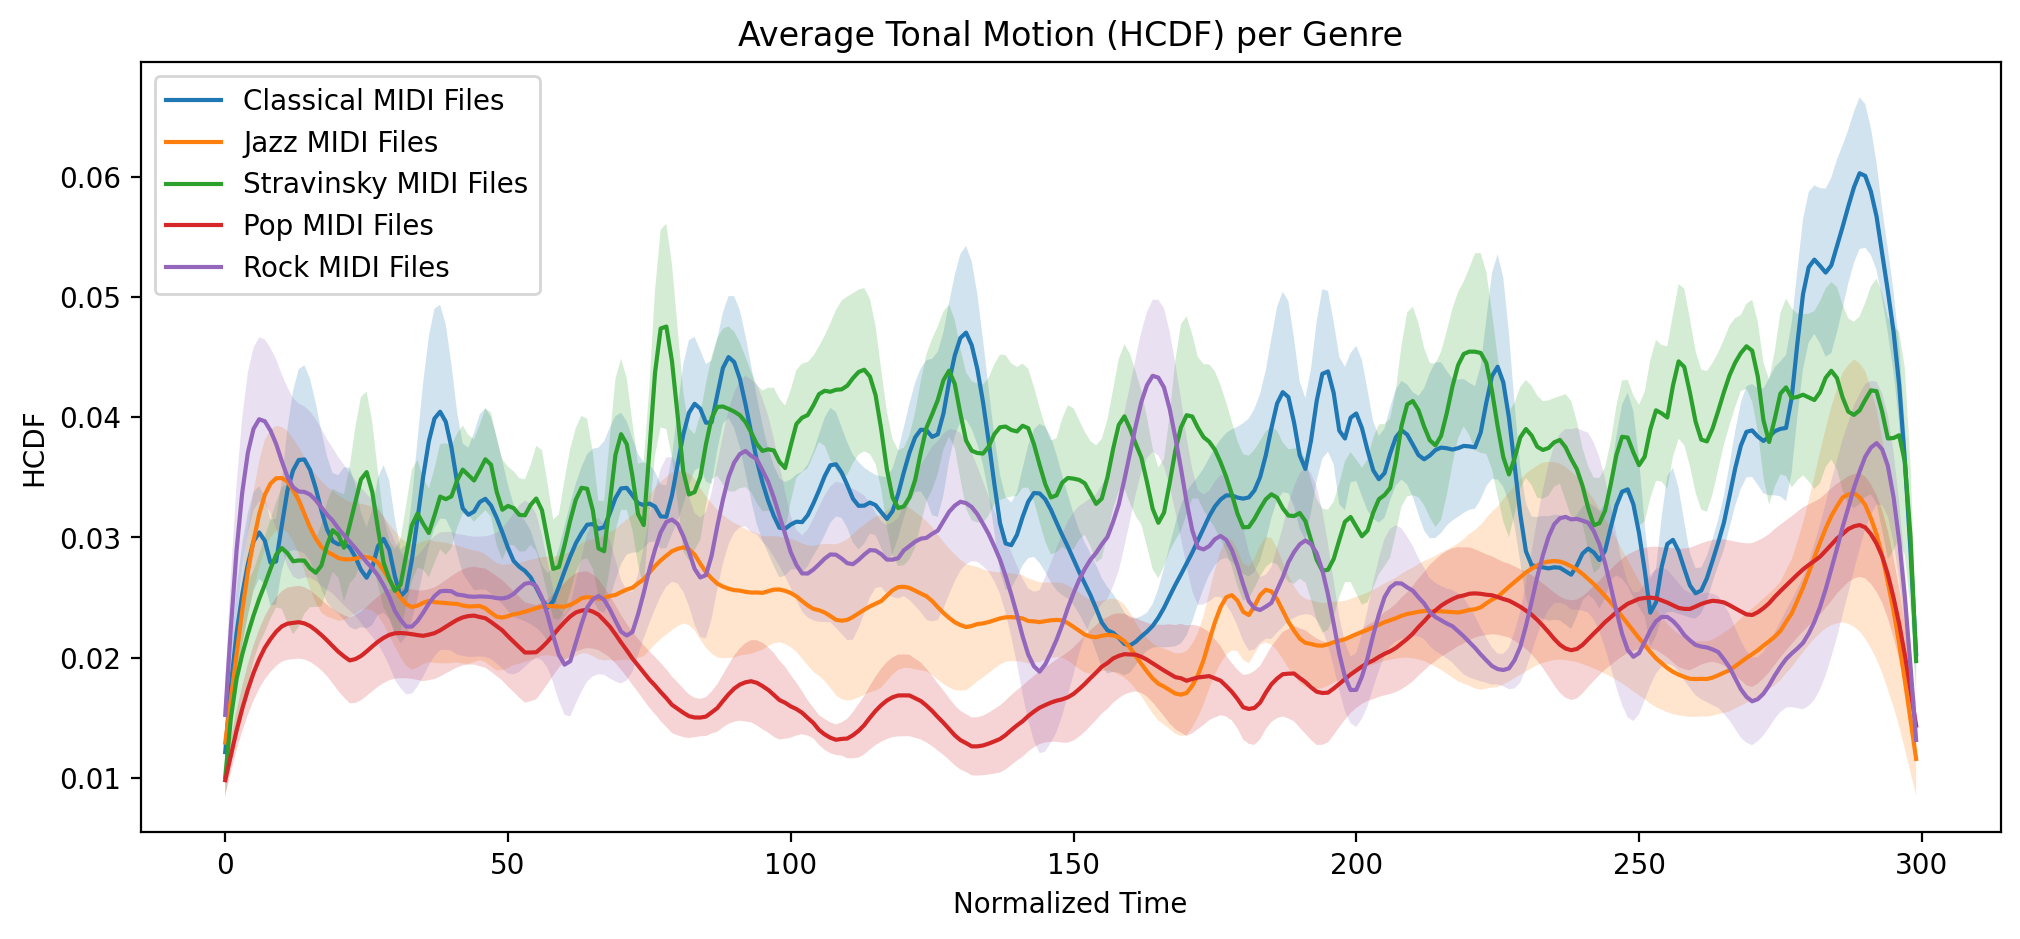

In [ ]:
plt.figure(figsize=(12,5))

for genre in genre_mean.keys():
    mean_curve = genre_mean[genre]
    sem_curve = genre_sem[genre]

    x = np.arange(TARGET_LEN)

    plt.plot(x, mean_curve, label=genre)
    plt.fill_between(x,
                     mean_curve - sem_curve,
                     mean_curve + sem_curve,
                     alpha=0.2)

plt.title("Average Tonal Motion (HCDF) per Genre")
plt.xlabel("Normalized Time")
plt.ylabel("HCDF")
plt.legend()
save_and_show()

In [ ]:
def six_d_distance(centroids_a, centroids_b):
    """
    Frame-wise Euclidean distance between two
    6D tonal centroid trajectories.
    Automatically aligns lengths.
    """
    min_len = min(len(centroids_a), len(centroids_b))

    if min_len == 0:
        return np.zeros(1)

    a = centroids_a[:min_len]
    b = centroids_b[:min_len]

    return np.linalg.norm(a - b, axis=1)

In [ ]:
# ---------------------------
# 6D Distance by Genre
# ---------------------------

dist_mean = {}
dist_sem = {}

for genre, files in GENRE_GROUPS.items():

    curves = []

    for f in files:
        ks_cent, _, _ = ks_time_pipeline(f)
        chr_cent, _ = chroma_pipeline(f)

        dist = six_d_distance(ks_cent, chr_cent)
        dist_fixed = resample_to_fixed_length(dist, TARGET_LEN)

        curves.append(dist_fixed)

    curves = np.array(curves)

    if len(curves) > 0:
        dist_mean[genre] = curves.mean(axis=0)
        dist_sem[genre] = curves.std(axis=0) / np.sqrt(len(curves))

plt.figure()

for genre in dist_mean:
    x = np.arange(TARGET_LEN)
    mean = dist_mean[genre]
    sem = dist_sem[genre]

    plt.plot(x, mean, label=genre)
    plt.fill_between(x, mean-sem, mean+sem, alpha=0.2)

plt.title("6D Distance (KS vs Chroma) by Genre")
plt.xlabel("Normalized Time")
plt.ylabel("Distance")
plt.legend()
save_and_show()

/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=5, data=b'Copyright \xa9 2006 by Bernd Krueger'>; getting generic Instrument
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
plt.figure()

groups = []
labels = []

for genre, files in GENRE_GROUPS.items():
    all_vals = []

    for f in files:
        ks_cent, _, _ = ks_time_pipeline(f)
        chr_cent, _ = chroma_pipeline(f)
        dist = six_d_distance(ks_cent, chr_cent)
        all_vals.extend(dist)

    if len(all_vals) > 0:
        groups.append(all_vals)
        labels.append(genre)

plt.violinplot(groups, showmeans=True)
plt.xticks(range(1, len(labels)+1), labels)
plt.ylabel("6D Distance")
plt.title("6D Distance Distribution by Genre")
save_and_show()

In [ ]:
# ---------------------------
# Frame-wise KAI by Genre
# ---------------------------

kai_time_mean = {}
kai_time_sem = {}

for genre, files in GENRE_GROUPS.items():

    curves = []

    for f in files:
        kai_curve = compute_KAI_time(f)
        kai_fixed = resample_to_fixed_length(kai_curve, TARGET_LEN)
        curves.append(kai_fixed)

    curves = np.array(curves)

    if len(curves) > 0:
        kai_time_mean[genre] = curves.mean(axis=0)
        kai_time_sem[genre] = curves.std(axis=0) / np.sqrt(len(curves))

plt.figure()

for genre in kai_time_mean:
    x = np.arange(TARGET_LEN)
    mean = kai_time_mean[genre]
    sem = kai_time_sem[genre]

    plt.plot(x, mean, label=genre)
    plt.fill_between(x, mean-sem, mean+sem, alpha=0.2)

plt.title("Frame-wise KAI by Genre")
plt.xlabel("Normalized Time")
plt.ylabel("KAI")
plt.legend()
save_and_show()

In [ ]:
plt.figure()

groups = []
labels = []

for genre, files in GENRE_GROUPS.items():
    all_vals = []

    for f in files:
        kai_curve = compute_KAI_time(f)
        all_vals.extend(kai_curve)

    if len(all_vals) > 0:
        groups.append(all_vals)
        labels.append(genre)

plt.violinplot(groups, showmeans=True)
plt.xticks(range(1, len(labels)+1), labels)
plt.ylabel("KAI")
plt.title("Frame-wise KAI Distribution by Genre")
save_and_show()

In [ ]:
# ---------------------------
# HCDF Distribution by Genre (Violin)
# ---------------------------

plt.figure(figsize=(10,5))

groups = []
labels = []

for genre, files in GENRE_GROUPS.items():

    all_vals = []

    for f in files:
        _, hcdf, _ = ks_time_pipeline(f, frame_size=1.0)
        all_vals.extend(hcdf)

    if len(all_vals) > 0:
        groups.append(all_vals)
        labels.append(genre)

plt.violinplot(groups, showmeans=True)
plt.xticks(range(1, len(labels)+1), labels)
plt.ylabel("HCDF")
plt.title("HCDF Distribution by Genre")
save_and_show()

/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Pr\xe4ludium und Fuge c-moll bwv847'>; getting generic Instrument
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Pr\xe4ludium und Fuge D-Dur bwv 850'>; getting generic Instrument
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Pr\xe4ludium und Fuge e-moll bwv 855'>; getting generic Instrument
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Pr\xe4

KeyboardInterrupt: 

<Figure size 1000x500 with 0 Axes>

In [ ]:
# ---------------------------
# 6D Distance (Single File Example)
# ---------------------------

example_genre = list(GENRE_GROUPS.keys())[0]
example_file = GENRE_GROUPS[example_genre][0]

ks_cent, _, _ = ks_time_pipeline(example_file)
chr_cent, _ = chroma_pipeline(example_file)

dist = six_d_distance(ks_cent, chr_cent)

plt.figure()
plt.plot(dist)
plt.title(f"6D Distance (KS vs Chroma)\n{example_genre}")
plt.xlabel("Frame")
plt.ylabel("6D Distance")
save_and_show()

In [ ]:
plt.figure()
plt.violinplot(dist)
plt.title("6D Distance Distribution (Single File)")
plt.ylabel("Distance")
save_and_show()

In [ ]:
# ---------------------------
# COMPUTE RAW COMPONENTS FIRST
# ---------------------------

kai_components = []

for genre, files in GENRE_GROUPS.items():
    for f in files:
        var_ks, tonnetz = compute_KAI(f)

        kai_components.append({
            "Genre": genre,
            "File": f,
            "Var_KS": var_ks,
            "Tonnetz_per_min": tonnetz
        })

kai_df = pd.DataFrame(kai_components)


# ---------------------------
# Z-SCORE NORMALIZATION
# ---------------------------

kai_df["Var_KS_z"] = zscore(kai_df["Var_KS"])
kai_df["Tonnetz_z"] = zscore(kai_df["Tonnetz_per_min"])


# ---------------------------
# FINAL KAI DEFINITION
# ---------------------------

kai_df["KAI"] = kai_df["Var_KS_z"] + kai_df["Tonnetz_z"]

In [ ]:
# ---------------------------
# KAI violin plot by genre
# ---------------------------

# Make sure kai_df has a 'Genre' column before running this
valid_genres = []
groups = []

for g in GENRE_GROUPS.keys():
    subset = kai_df[kai_df['Genre'] == g].KAI.dropna()
    if len(subset) > 1:  # Only include genres with more than 1 sample
        valid_genres.append(g)
        groups.append(subset.values)

plt.figure(figsize=(10,5))
plt.violinplot(groups, showmeans=True)
plt.xticks(range(1, len(valid_genres)+1), valid_genres)
plt.ylabel("KAI")
plt.title("Key Ambiguity Index (KAI) by Genre")
save_and_show()

In [ ]:
# ---------------------------
#

In [ ]:
# ==========================================
# IMPRESSIVE ROBUSTNESS PLOT: ALL FILES, 4 CONDITIONS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem  # standard error

# Parameters
FRAME_SIZE = 2.0
SIGMA_VALUES = [0.0, 4]       # No smoothing vs Gaussian smoothing
JITTER_VALUES = [0.0, 0.05]   # No jitter vs 50ms jitter
TARGET_LEN = 300              # normalized length for plotting

# Four conditions: (jitter, sigma)
conditions = [
    (0.0, 0.0),
    (0.0, 4),
    (0.05, 0.0),
    (0.05, 4)
]

condition_labels = [f"jitter={j}, sigma={s}" for j,s in conditions]
colors = ["blue", "orange", "green", "red"]

# Loop through each genre
for genre, files in GENRE_GROUPS.items():
    all_curves = {label: [] for label in condition_labels}

    # Compute KAI for all files in all 4 conditions
    for f in files:
        for idx, (jitter_val, sigma_val) in enumerate(conditions):
            try:
                kai_curve = compute_KAI_time(
                    f,
                    frame_size=FRAME_SIZE,
                    sigma_ks=sigma_val,
                    sigma_chr=sigma_val,
                    jitter=jitter_val
                )
                # Resample to TARGET_LEN for uniform comparison
                kai_fixed = np.interp(
                    np.linspace(0, len(kai_curve)-1, TARGET_LEN),
                    np.arange(len(kai_curve)),
                    kai_curve
                )
                all_curves[condition_labels[idx]].append(kai_fixed)
            except:
                continue

    # Convert to numpy arrays
    for key in all_curves:
        all_curves[key] = np.array(all_curves[key])

    # ---------------------------
    # Mean ± SEM curves
    # ---------------------------
    plt.figure(figsize=(12,5))
    plt.title(f"{genre}: KAI Robustness (Mean ± SEM)")
    x = np.arange(TARGET_LEN)

    for idx, label in enumerate(condition_labels):
        data = all_curves[label]
        if data.shape[0] == 0:
            continue
        mean_curve = data.mean(axis=0)
        sem_curve = sem(data, axis=0)
        plt.plot(x, mean_curve, color=colors[idx], label=label)
        plt.fill_between(x, mean_curve-sem_curve, mean_curve+sem_curve, color=colors[idx], alpha=0.2)

    plt.xlabel("Normalized Frame")
    plt.ylabel("KAI")
    plt.legend()
    save_and_show()

    # ---------------------------
    # Violin plots of frame-wise distributions
    # ---------------------------
    plt.figure(figsize=(10,5))
    groups = []
    labels_violin = []
    for idx, label in enumerate(condition_labels):
        data = all_curves[label]
        if data.shape[0] == 0:
            continue
        all_frames = data.flatten()  # combine all frames across files
        groups.append(all_frames)
        labels_violin.append(label)

    plt.violinplot(groups, showmeans=True)
    plt.xticks(range(1, len(labels_violin)+1), labels_violin)
    plt.ylabel("KAI")
    plt.title(f"{genre}: KAI Distribution Across Frames")
    save_and_show()

In [ ]:
# ==========================================
# N0. PATCH: redefine ks_time_pipeline with pure-numpy KS
#     W=1s non-overlapping frames (original notebook parameters)
# ==========================================

def ks_time_pipeline(midi_file, frame_size=1.0, hop=1.0, sigma=2, jitter=0.0):
    """
    Rolling KS key-strength pipeline (pure numpy — no music21 timeout).
    frame_size : window length in seconds (default 1 s — original parameters)
    hop        : step size in seconds    (default 1 s — non-overlapping)
    """
    flat = load_flat_stream(midi_file)
    total_length = flat.highestTime

    if total_length == 0:
        return np.zeros((1, 6)), np.zeros(1), np.zeros(1)

    t0 = np.random.uniform(-jitter, jitter) if jitter > 0 else 0.0
    times = np.arange(max(0.0, t0), total_length - frame_size + 1e-9, hop)

    if len(times) == 0:
        times = np.array([0.0])

    centroids = []
    ks_strengths = []

    for t in times:
        notes_in_window = flat.getElementsByOffset(
            t, t + frame_size,
            includeEndBoundary=False,
            mustBeginInSpan=False,
            mustFinishInSpan=False
        )
        w_stream = stream.Stream(notes_in_window)

        if len(w_stream.notes) == 0:
            centroids.append(np.zeros(6))
            ks_strengths.append(0.0)
        else:
            # Binary chroma from window notes
            ch = np.zeros(12)
            for note in w_stream.notes:
                ch[note.pitch.pitchClass] += 1
            if ch.sum() > 0:
                ch /= ch.sum()
            centroids.append(tonal_centroid(ch))
            ks_strengths.append(ks_key_strength(ch))

    centroids = np.array(centroids)
    if sigma > 0 and len(centroids) > 1:
        centroids = gaussian_filter1d(centroids, sigma=sigma, axis=0)

    hcdf = compute_hcdf(centroids)
    return centroids, hcdf, np.array(ks_strengths)


def compute_KAI(midi_file, frame_size=1.0, hop=1.0, sigma_ks=2, sigma_chr=8, jitter=0.0):
    """
    Piece-level KAI components.
    Returns (var_ks_strength, tonnetz_per_min).
    Default frame_size=1s, hop=1s — original non-overlapping parameters.
    """
    _, _, ks_strengths = ks_time_pipeline(
        midi_file, frame_size=frame_size, hop=hop, sigma=sigma_ks, jitter=jitter
    )
    _, hcdf_chr = chroma_pipeline(midi_file, frame_size=frame_size, sigma=sigma_chr)

    var_ks_strength = float(np.var(ks_strengths)) if len(ks_strengths) > 1 else 0.0
    duration_min    = pretty_midi.PrettyMIDI(midi_file).get_end_time() / 60.0
    tonnetz_per_min = float(hcdf_chr.sum() / duration_min) if duration_min > 0 else 0.0
    return var_ks_strength, tonnetz_per_min


def ks_key_strength(ch):
    """Pearson correlation vs 24 K&K 1982 profiles (pure numpy)."""
    KS_MAJOR = np.array([6.35,2.23,3.48,2.33,4.38,4.09,2.52,5.19,2.39,3.66,2.29,2.88])
    KS_MINOR = np.array([6.33,2.68,3.52,5.38,2.60,3.53,2.54,4.75,3.98,2.69,3.34,3.17])
    c = ch - ch.mean(); cn = np.linalg.norm(c)
    if cn == 0: return 0.0
    best = -1.0
    for profile in (KS_MAJOR, KS_MINOR):
        for r in range(12):
            pv = np.roll(profile, r); pv = pv - pv.mean(); pn = np.linalg.norm(pv)
            if pn == 0: continue
            rv = float(np.dot(c, pv) / (cn * pn))
            if rv > best: best = rv
    return best


print("Patched ks_time_pipeline (W=1s, hop=1s, pure-numpy KS) and compute_KAI.")


In [ ]:
# ==========================================
# N0b. RECOMPUTE kai_df with W=1s, hop=1s
# ==========================================
from scipy.stats import zscore as _zscore

kai_components = []
print("Recomputing KAI components (W=1s, hop=1s) — this may take a few minutes...")
for genre, files in GENRE_GROUPS.items():
    print(" ", genre)
    for f in files:
        var_ks, tonnetz = compute_KAI(f)
        kai_components.append({
            "Genre": genre, "File": f,
            "Var_KS": var_ks, "Tonnetz_per_min": tonnetz
        })

kai_df = pd.DataFrame(kai_components)
kai_df["Var_KS_z"]    = _zscore(kai_df["Var_KS"])
kai_df["Tonnetz_z"]   = _zscore(kai_df["Tonnetz_per_min"])
kai_df["KAI"]         = kai_df["Var_KS_z"] + kai_df["Tonnetz_z"]
kai_df["File_base"]   = kai_df["File"].apply(os.path.basename)
print("Done. Shape:", kai_df.shape)
print(kai_df[["Genre","File_base","Var_KS","Tonnetz_per_min","KAI"]].to_string())
ii

In [ ]:
# ==========================================
# N1. PIECE-LEVEL MASTER TABLE
# Unit of analysis = 1 row per piece (resolves pseudoreplication)
# ==========================================
PIECE_CACHE_CSV = os.path.join(path_to_folder, "piece_level_metrics.csv")

rows = []
print("Building piece-level metrics (chroma pipeline at 1s frames)...")
for genre, files in GENRE_GROUPS.items():
    print(" ", genre)
    for f in files:
        chr_cent, hcdf_chr = chroma_pipeline(f, frame_size=1.0)
        ks_cent, _, _      = ks_time_pipeline(f)           # W=5s, hop=1s
        dist6d             = six_d_distance(ks_cent, chr_cent)
        rows.append({
            "Genre":      genre,
            "File":       os.path.basename(f),
            "HCDF_mean":  float(np.mean(hcdf_chr)),
            "HCDF_med":   float(np.median(hcdf_chr)),
            "Dist6D_mean":float(np.mean(dist6d)),
            "Dist6D_med": float(np.median(dist6d)),
        })

piece_df = pd.DataFrame(rows)
piece_df = piece_df.merge(
    kai_df[["File_base","Var_KS","Tonnetz_per_min","Var_KS_z","Tonnetz_z","KAI","Genre"]],
    left_on=["File","Genre"], right_on=["File_base","Genre"], how="left"
)
piece_df.to_csv(PIECE_CACHE_CSV, index=False)
print("Saved:", PIECE_CACHE_CSV)
assert len(piece_df) == 50, f"Expected 50 pieces, got {len(piece_df)}"
METRICS = ["KAI", "HCDF_mean", "Dist6D_mean"]
print(piece_df[["Genre","File","KAI","HCDF_mean","Dist6D_mean"]].to_string())


In [ ]:
# ==========================================
# N2. PER-GENRE DESCRIPTIVE STATISTICS  →  Table 3
# ==========================================
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)

desc = piece_df.groupby("Genre")[METRICS].agg(["count","median",q25,q75])
print(desc.round(4).to_string())

print("\n--- LaTeX rows for Table 3 (paste into paper) ---")
for g, r in desc.iterrows():
    genre_short = g.replace(" MIDI Files","")
    n    = int(r[("KAI","count")])
    kmed = r[("KAI","median")];   kq1 = r[("KAI","q25")];   kq3 = r[("KAI","q75")]
    hmed = r[("HCDF_mean","median")]; hq1 = r[("HCDF_mean","q25")]; hq3 = r[("HCDF_mean","q75")]
    dmed = r[("Dist6D_mean","median")]
    print(f"{genre_short} & {n} & {kmed:.2f} & {kq1:.2f}--{kq3:.2f} & "
          f"{hmed:.3f} & {hq1:.3f}--{hq3:.3f} & {dmed:.3f} \\\\")


In [ ]:
# ==========================================
# N3. KRUSKAL-WALLIS  →  Results section inline
# ==========================================
from scipy.stats import kruskal, permutation_test

genres_sorted = sorted(piece_df["Genre"].unique())
print("=== KRUSKAL-WALLIS (piece-level) ===")
for m in METRICS:
    samples = [piece_df.loc[piece_df.Genre==g, m].dropna().values for g in genres_sorted]
    H, p_asymp = kruskal(*samples)
    df_kw = len(samples) - 1
    print(f"{m:14s}  H({df_kw}) = {H:.4f},  p_asymp = {p_asymp:.4f}")

print("\n--- Paste into Results (Table 2 caption / inline): ---")
for m in METRICS:
    samples = [piece_df.loc[piece_df.Genre==g, m].dropna().values for g in genres_sorted]
    H, p = kruskal(*samples)
    print(f"  {m}: H(4) = {H:.2f}, p = {p:.3f}")


In [ ]:
# ==========================================
# N4. DUNN POST-HOC: z, raw p, BH-adjusted p
# ==========================================
import itertools as _it
from scipy.stats import rankdata as _rankdata, norm as _norm

def dunn_full(df, val_col, group_col):
    vals = df[val_col].values
    grps = df[group_col].values
    N    = len(vals)
    R    = _rankdata(vals)
    _, cnts = np.unique(vals, return_counts=True)
    tie  = np.sum(cnts**3 - cnts) / (12.0*(N-1))
    A    = N*(N+1)/12.0 - tie
    pairs = list(_it.combinations(sorted(np.unique(grps)), 2))
    out   = []
    for g1, g2 in pairs:
        r1, r2 = R[grps==g1], R[grps==g2]
        z      = (r1.mean() - r2.mean()) / np.sqrt(A*(1/len(r1) + 1/len(r2)))
        p_raw  = float(2 * _norm.sf(abs(z)))
        out.append({"Pair": f"{g1} vs {g2}", "z": z, "p_raw": p_raw})
    res = pd.DataFrame(out)
    # Benjamini-Hochberg
    m   = len(res)
    ord = np.argsort(res.p_raw.values)
    adj = np.empty(m); prev = 1.0
    for rank_i, idx in list(enumerate(ord, 1))[::-1]:
        prev = min(prev, res.p_raw.values[idx] * m / rank_i)
        adj[idx] = prev
    res["p_BH"] = adj
    return res

dunn_tables = {}
for metric in METRICS:
    res = dunn_full(piece_df, metric, "Genre")
    dunn_tables[metric] = res.copy()
    # Cross-check BH vs scikit_posthocs
    sp_check = sp.posthoc_dunn(piece_df, val_col=metric, group_col="Genre", p_adjust="fdr_bh")
    for _, row in res.iterrows():
        g1, g2 = row.Pair.split(" vs ")
        delta_bh = abs(sp_check.loc[g1, g2] - row.p_BH)
        assert delta_bh < 1e-5, f"BH mismatch {row.Pair} ({metric}): {delta_bh}"
    print(f"\n===== Dunn: {metric} (cross-check passed) =====")
    print(res.round(4).to_string(index=False))


In [ ]:
# ==========================================
# N5. CLIFF'S DELTA + LaTeX output for Table 2
# ==========================================
def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    gt = (x[:,None] > y[None,:]).sum()
    lt = (x[:,None] < y[None,:]).sum()
    return float(gt - lt) / (len(x)*len(y))

def delta_label(d):
    a = abs(d)
    if a < 0.147: return "negligible"
    if a < 0.33:  return "small"
    if a < 0.474: return "medium"
    return "large"

for metric in METRICS:
    res = dunn_tables[metric].copy()
    deltas = []
    for pair in res.Pair:
        g1, g2 = pair.split(" vs ")
        d = cliffs_delta(
            piece_df.loc[piece_df.Genre==g1, metric].dropna().values,
            piece_df.loc[piece_df.Genre==g2, metric].dropna().values
        )
        deltas.append(d)
    res["cliffs_delta"] = deltas
    res["magnitude"]    = res.cliffs_delta.apply(delta_label)
    dunn_tables[metric] = res
    res.to_csv(os.path.join(path_to_folder, f"dunn_cliffs_{metric}.csv"), index=False)
    print(f"\n--- Table 2 LaTeX rows ({metric}) ---")
    print(f"{'Pair':<35} {'z':>6} {'p_raw':>7} {'p_BH':>7} {'delta':>7}  magnitude")
    for _, r in res.iterrows():
        pair_short = r.Pair.replace(" MIDI Files","")
        print(f"{pair_short:<35} {r.z:6.2f} {r.p_raw:7.3f} {r.p_BH:7.3f} {r.cliffs_delta:7.2f}  {r.magnitude}")


In [ ]:
# ==========================================
# N6. CORPUS METADATA  →  Table 1
# NOTE: Composer and Source columns must be
#       filled in manually by Mehak from download notes.
# ==========================================
meta_rows = []
for genre, files in GENRE_GROUPS.items():
    for f in files:
        pm    = pretty_midi.PrettyMIDI(f)
        tempi = pm.get_tempo_changes()[1]
        meta_rows.append({
            "Genre":      genre.replace(" MIDI Files",""),
            "Title":      os.path.splitext(os.path.basename(f))[0],
            "Composer":   "[TBD]",
            "Source":     "[TBD]",
            "Duration_s": round(pm.get_end_time(), 1),
            "Key":        "[TBD]",
            "Tempo_bpm":  round(float(np.median(tempi)) if len(tempi) else float("nan"), 1),
            "Tracks":     len(pm.instruments),
            "Note_count": sum(len(i.notes) for i in pm.instruments),
            "Type":       "[TBD]",
        })

meta_df = pd.DataFrame(meta_rows).sort_values(["Genre","Title"]).reset_index(drop=True)
meta_csv = os.path.join(path_to_folder, "corpus_metadata.csv")
meta_df.to_csv(meta_csv, index=False)
print("Saved:", meta_csv)
print(meta_df[["Genre","Title","Duration_s","Tempo_bpm","Tracks","Note_count"]].to_string())
print("\n--- [ACTION NEEDED] Fill Composer, Source, Key, Type columns in corpus_metadata.csv ---")


In [ ]:
# ==========================================
# N7. ROBUSTNESS: Spearman ρ vs baseline
#     + weight sensitivity  →  Appendix A Table A1
# ==========================================
from scipy.stats import spearmanr, zscore as _z2

ROBUST_CSV = os.path.join(path_to_folder, "robustness_piece_kai.csv")

conditions_rob = {
    "W=5s,sigma=2,j=0  [BASELINE]": dict(frame_size=5.0, hop=1.0, sigma_ks=2, sigma_chr=8, jitter=0.0),
    "W=3s,sigma=2,j=0":             dict(frame_size=3.0, hop=1.0, sigma_ks=2, sigma_chr=8, jitter=0.0),
    "W=10s,sigma=2,j=0":            dict(frame_size=10.0,hop=1.0, sigma_ks=2, sigma_chr=8, jitter=0.0),
    "W=5s,sigma=1,j=0":             dict(frame_size=5.0, hop=1.0, sigma_ks=1, sigma_chr=4, jitter=0.0),
    "W=5s,sigma=4,j=0":             dict(frame_size=5.0, hop=1.0, sigma_ks=4, sigma_chr=16,jitter=0.0),
    "W=5s,sigma=2,j=0.02":          dict(frame_size=5.0, hop=1.0, sigma_ks=2, sigma_chr=8, jitter=0.02),
}

print("Running robustness conditions (may take several minutes)...")
rob_rows = []
for cname, kw in conditions_rob.items():
    print(" ", cname)
    for genre, files in GENRE_GROUPS.items():
        for f in files:
            vk, tp = compute_KAI(f, **kw)
            rob_rows.append({"Condition":cname,"Genre":genre,"File":os.path.basename(f),
                              "Var_KS":vk,"Tonnetz_per_min":tp})

rob_df = pd.DataFrame(rob_rows)
# Corpus-wide z per condition
rob_df["KAI"] = rob_df.groupby("Condition")[["Var_KS"]].transform(_z2)["Var_KS"] \
              + rob_df.groupby("Condition")[["Tonnetz_per_min"]].transform(_z2)["Tonnetz_per_min"]
rob_df.to_csv(ROBUST_CSV, index=False)

base_vals = rob_df[rob_df.Condition.str.startswith("W=5s,sigma=2,j=0  [BASELINE]")].set_index("File")["KAI"]

print("\n=== Spearman ρ (piece-level KAI vs baseline) ===")
for cname in conditions_rob:
    cur  = rob_df[rob_df.Condition==cname].set_index("File")["KAI"].reindex(base_vals.index)
    rho, p = spearmanr(base_vals, cur)
    gm_b = rob_df[rob_df.Condition.str.startswith("W=5s,sigma=2,j=0  [BASELINE]")].groupby("Genre")["KAI"].mean().rank()
    gm_c = rob_df[rob_df.Condition==cname].groupby("Genre")["KAI"].mean().rank()
    rho_g, _ = spearmanr(gm_b, gm_c)
    print(f"  {cname:<35}  rho_piece={rho:.3f} (p={p:.3g})  rho_genre_rank={rho_g:.2f}")

print("\n=== Weight sensitivity (Issue 7): KAI_alpha = 2a*z(VarKS) + 2(1-a)*z(Tonnetz) ===")
for alpha in [0.25, 0.50, 0.75]:
    kai_a = 2*alpha*piece_df["Var_KS_z"] + 2*(1-alpha)*piece_df["Tonnetz_z"]
    rho, _ = spearmanr(piece_df["KAI"], kai_a)
    print(f"  alpha={alpha}: Spearman rho vs equal-weight KAI = {rho:.3f}")
